## Combining GMNs with ESNs. Using Echoes. 

This code was created on Aug 7th, expands on code "00".

https://github.com/fabridamicelli/echoes


In [11]:
import os
print("Working dir is now:", os.getcwd())

DATA_PATH = "/Users/adrian/Documents/01_projects/14_4D_lab/data"
OUTPUT_PATH = "/Users/adrian/Documents/01_projects/14_4D_lab/output/03_ESNs_on_binarized_connectomes"

PREPROCESSED_PATH = DATA_PATH + "/preprocessed/01_first_analysises"


# create output path if it does not exist
if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

if not os.path.exists(PREPROCESSED_PATH):
    os.makedirs(PREPROCESSED_PATH)

Working dir is now: /Users/adrian/Documents/01_projects/14_4D_lab


In [2]:
import numpy as np
import scipy.io
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from echoes.esn import ESNRegressor

from src.utils.saving_conventions import time_stamp_for_saving

In [3]:
connectomes_binarized = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/connectomes_binarized.npy")
consensus_connectome_bin = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/consensus_connectome_bin.npy")
all_connectomes = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/all_connectomes.npy")

df_identifiers = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/df_identifiers.csv") 

# df_graph_measures_bin = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/df_graph_measures_bin.csv")
df_graph_measures_all = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/df_graph_measures_all.csv")
df_graph_measures = df_graph_measures_all

In [4]:
# one_connectome = connectomes_binarized[0]
one_connectome = all_connectomes[0]  # Use the first connectome for testing. WHAT DO WE DO WITH THE BINARIZED CONNECTOMES? RANDOM WEIGHTS? 
one_connectome.shape

W = one_connectome.copy()

In [5]:
# first_esn = ESNRegressor(
#     n_reservoir=100,  # number of steps to generate pattern
#     W=W,  # reservoir weight matrix (attention: this is a binary connectome, not a weight matrix)
#     spectral_radius=0.99, # spectral radius of the reservoir weight matrix
#     noise=0, # scaling of uniform noise added to the reservoir state at each step
#     # leak_rate, bias, activation, activation_out, fit_only_states, regression_method, ridge_alpha, ridge_fit_intercept, ridge_max_iter
#     # ridge_tol, ridge_solver, ridge_sample_weight, n_transient, store_states_train, store_states_pred
# )

# first_esn

# first_esn.fit(X=None, y=np.random.rand(10,))
# # fit, predict, score. 

# mc with squared pearson. 

## Evaluate binarized empirical connectomes' memory capacity and sequence recall

In [9]:
# Note: I am using the binarized connectomes here, but I am turning them into a weight matrix by assigning random weights to the non-zero entries.

import time
from src.ESNs.generate_weight_matrices_bio_no_rank import build_weight_matrix_from_bin_conn
from src.ESNs.test_memory_capacity import evaluate_memory_capacity
from src.ESNs.test_sequence_recall import evaluate_sequence_recall

# Iterate over subjects and compute memory capacity and sequence recall
results = []
durations = []
for i, one_connectome in enumerate(connectomes_binarized):
    print(f"Processing network_index {i}. Total number connectomes: {connectomes_binarized.shape[0]}...")

    # Build reservoir from connectome
    start_time = time.time()
    W = build_weight_matrix_from_bin_conn(one_connectome, 
                                                      spectral_radius=0.99, 
                                                      rank=False)
    time_building_reservoir = time.time() - start_time

    # Evaluate memory capacity 
    mc = evaluate_memory_capacity(W, 
                                  n_lags=50, 
                                  train_len=4000, test_len=1000,
                                  n_runs=10, 
                                  random_state=i)
    time_evaluating_mc = time.time() - start_time - time_building_reservoir

    # Evaluate sequence recall
    seq = evaluate_sequence_recall(W, 
                                   pattern_lengths=range(5, 26), # damicelli tried out 100 different networks with new weights per pattern length
                                    train_trials=800, test_trials=200,
                                    n_runs=5,
                                    random_state=i)
    time_evaluating_seq_recall = time.time() - start_time - time_building_reservoir - time_evaluating_mc

    # Store results for this subject
    results.append({
        "network_index": i, 
        "memory_capacity": mc,
        "sequence_recall": seq
    })
    # Store durations for each step
    durations.append({
        "subject": i,
        "time_building_reservoir": time_building_reservoir,
        "time_evaluating_mc": time_evaluating_mc,
        "time_evaluating_seq_recall": time_evaluating_seq_recall,
    })
    # break

results, durations

# One run: 12 seconds -> would take 14 minutes for 70 subjects

Processing network_index 0. Total number connectomes: 70...


/Users/adrian/Documents/01_projects/14_4D_lab/src/ESNs/generate_weight_matrices_bio_no_rank.py:75: RuntimeWarning: divide by zero encountered in matmul
  vec = matrix @ vec
/Users/adrian/Documents/01_projects/14_4D_lab/src/ESNs/generate_weight_matrices_bio_no_rank.py:75: RuntimeWarning: overflow encountered in matmul
  vec = matrix @ vec
/Users/adrian/Documents/01_projects/14_4D_lab/src/ESNs/generate_weight_matrices_bio_no_rank.py:75: RuntimeWarning: invalid value encountered in matmul
  vec = matrix @ vec
/Users/adrian/Documents/01_projects/14_4D_lab/src/ESNs/generate_weight_matrices_bio_no_rank.py:79: RuntimeWarning: divide by zero encountered in matmul
  return float(np.linalg.norm(matrix @ vec) / np.linalg.norm(vec))
/Users/adrian/Documents/01_projects/14_4D_lab/src/ESNs/generate_weight_matrices_bio_no_rank.py:79: RuntimeWarning: overflow encountered in matmul
  return float(np.linalg.norm(matrix @ vec) / np.linalg.norm(vec))
/Users/adrian/Documents/01_projects/14_4D_lab/src/ESNs/g

Processing network_index 1. Total number connectomes: 70...


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  W_out = (np.linalg.pinv(full_states) @ outputs).T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: overflow encountered in matmul
  W_out = (np.linalg.pinv(full_states) @ outputs).T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: invalid value

Processing network_index 2. Total number connectomes: 70...


...

/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  W_out = (np.linalg.pinv(full_states) @ outputs).T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: overflow encountered in matmul
  W_out = (np.linalg.pinv(full_states) @ outputs).T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: invalid value

Processing network_index 68. Total number connectomes: 70...


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  W_out = (np.linalg.pinv(full_states) @ outputs).T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: overflow encountered in matmul
  W_out = (np.linalg.pinv(full_states) @ outputs).T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: invalid value

Processing network_index 69. Total number connectomes: 70...


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  W_out = (np.linalg.pinv(full_states) @ outputs).T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: overflow encountered in matmul
  W_out = (np.linalg.pinv(full_states) @ outputs).T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: invalid value

In [13]:
esn_results_df = pd.DataFrame(results)
esn_results_df.to_csv(OUTPUT_PATH + f"/esn_results_{time_stamp_for_saving()}.csv", index=False)

esn_durations_df = pd.DataFrame(durations)
esn_durations_df.to_csv(OUTPUT_PATH + f"/esn_durations_{time_stamp_for_saving()}.csv", index=False)

## Evaluate


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_52616/1295129658.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mean_r2_sr[key] for key in sorted(mean_r2_sr.keys())],


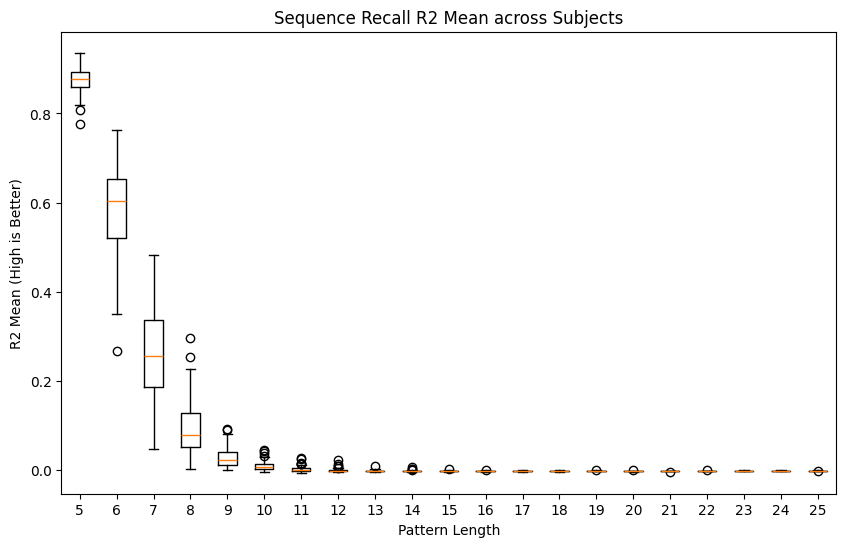

In [ ]:
mean_r2_sr = {}

for subject in esn_results_df["sequence_recall"].values: 
    # print(subject.keys()) # dict keys 5,6,7,8,9,...,25 
    for key in subject.keys():
        if key not in mean_r2_sr:
            mean_r2_sr[key] = []
        mean_r2_sr[key].append(subject[key]["r2_mean"])

    # print(subject[5])
    # print(subject[5]["r2_mean"])

# plot boxplots with the r2 mean for each key 
plt.figure(figsize=(10, 6))
plt.boxplot([mean_r2_sr[key] for key in sorted(mean_r2_sr.keys())],
            labels=sorted(mean_r2_sr.keys()))
plt.title("Sequence Recall R2 Mean across Subjects")
plt.xlabel("Pattern Length")
plt.ylabel("R2 Mean (High is Better)")
# plt.savefig(OUTPUT_PATH + f"/esn_sequence_recall_r2_mean_{time_stamp_for_saving()}.png")
plt.show()

performance_metric = np.mean(mean_r2_sr[key]) # does this work? 
print("The performance of this sequence_recall task for this model is:", performance_metric, ".")

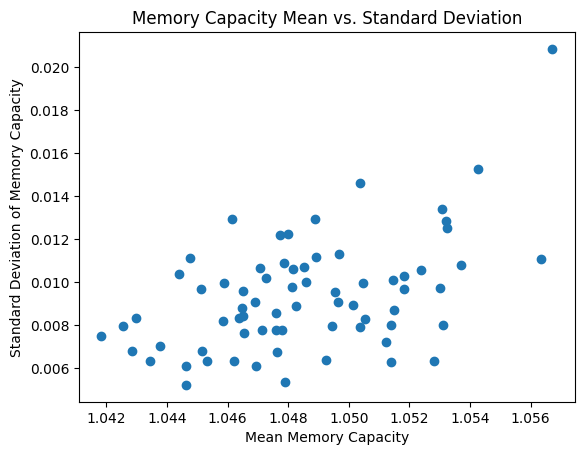

In [45]:
# those are mean and std of each subject's memory capacity

# esn_results_df["memory_capacity"].values

mc_mean = [subject["mc_mean"] for subject in esn_results_df["memory_capacity"].values]
mc_std = [subject["mc_std"] for subject in esn_results_df["memory_capacity"].values]

# for subject in esn_results_df["memory_capacity"].values: 
#     print(subject.keys()) # mc_mean, mc_std

plt.scatter(mc_mean, mc_std)
plt.xlabel("Mean Memory Capacity")
plt.ylabel("Standard Deviation of Memory Capacity")
plt.title("Memory Capacity Mean vs. Standard Deviation")
# plt.savefig(OUTPUT_PATH + f"/esn_memory_capacity_mean_std_{time_stamp_for_saving()}.png")
plt.show()


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_52616/3438636614.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([esn_durations_df["time_building_reservoir"],


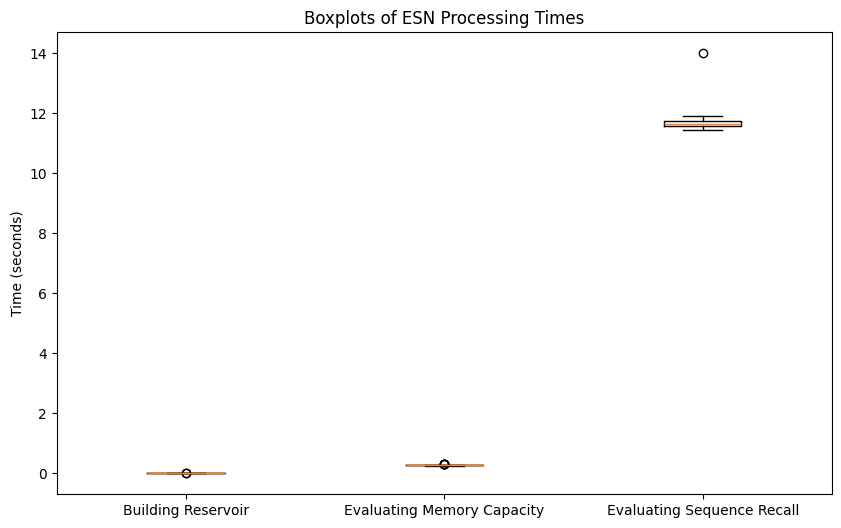

In [37]:
# plot boxplots with the durations of each step 
plt.figure(figsize=(10, 6))
plt.boxplot([esn_durations_df["time_building_reservoir"],
             esn_durations_df["time_evaluating_mc"],
             esn_durations_df["time_evaluating_seq_recall"]],
            labels=["Building Reservoir", "Evaluating Memory Capacity", "Evaluating Sequence Recall"])
plt.title("Boxplots of ESN Processing Times")
plt.ylabel("Time (seconds)")
# plt.savefig(OUTPUT_PATH + f"/esn_processing_times_{time_stamp_for_saving()}.png")
plt.show()

In [11]:
# combine graph_measures_df and esn_results_df
# combined_df = pd.merge(graph_measures_df, esn_results_df, on="network_index")
# combined_df

NameError: name 'graph_measures_df' is not defined